# Laboratorio 3 
## Relaciones cuantitativas con el precio

En este notebook se desarrolla la parte de análisis de variables numéricas vs precio.

### Objetivos
1. Construir una **matriz de correlación**.
2. Identificar las variables numéricas más relacionadas con el **precio**.
3. Explorar **relaciones bivariadas** entre precio y variables numéricas relevantes.
4. Realizar **pruebas de normalidad** y evaluar posibles **transformaciones**.
5. Redactar una **interpretación técnica** sobre qué variables parecen mejores predictoras del precio.

> Nota: este notebook está pensado para correr dentro de la estructura del proyecto del grupo.  
> Busca automáticamente `listings.RData` en varias rutas posibles.

In [13]:
# Librerías
import os
import warnings
warnings.filterwarnings("ignore")

import pyreadr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro, skew, kurtosis, spearmanr

plt.rcParams["figure.figsize"] = (9, 5)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 1. Carga del dataset

In [14]:
# Buscar el archivo en varias rutas posibles
possible_paths = [
    os.path.join("data", "listings.RData"),
    "listings.RData",
    os.path.join(".", "data", "listings.RData"),
    os.path.join("..", "data", "listings.RData")
]

data_path = None
for p in possible_paths:
    if os.path.exists(p):
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError("No se encontró listings.RData en las rutas esperadas.")

result = pyreadr.read_r(data_path)
df = result["listings"].copy()

print("Ruta encontrada:", data_path)
print("Dimensiones originales:", df.shape)

Ruta encontrada: data\listings.RData
Dimensiones originales: (171748, 80)


## 2. Limpieza básica de la variable respuesta

Primero se transforma `price` a formato numérico.  
Luego se crean variables auxiliares que se usarán en el análisis:
- `price_clean`: precio limpio en formato numérico.
- `log_price`: transformación logarítmica para reducir asimetría.
- `bedrooms_num` y `beds_num`: conversiones numéricas si venían como texto.

In [15]:
# Limpieza de price
df["price_clean"] = (
    df["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["price_clean"] = pd.to_numeric(df["price_clean"], errors="coerce")

# Conversión de columnas numéricas guardadas como texto
for col in ["bedrooms", "beds"]:
    if col in df.columns:
        df[f"{col}_num"] = pd.to_numeric(df[col], errors="coerce")

# Eliminar filas sin precio válido
df_num = df.dropna(subset=["price_clean"]).copy()

# Transformación logarítmica
df_num["log_price"] = np.log1p(df_num["price_clean"])

print("Filas con precio válido:", df_num.shape[0])
print(df_num[["price_clean", "log_price"]].describe())

Filas con precio válido: 76246
       price_clean   log_price
count  76,246.0000 76,246.0000
mean      750.5092      5.3876
std     4,250.6069      0.9903
min         8.0000      2.1972
25%       120.0000      4.7958
50%       193.0000      5.2679
75%       326.0000      5.7900
max    50,123.0000     10.8223


## 3. Selección de variables numéricas

Se toman únicamente variables numéricas con potencial explicativo.  
Se excluyen identificadores o columnas que no aportan directamente al análisis explicativo del precio.

In [16]:
# Variables numéricas del dataset
numeric_cols = df_num.select_dtypes(include=[np.number]).columns.tolist()

# Excluir identificadores o variables poco útiles para correlación explicativa
exclude_cols = [
    "id", "scrape_id", "host_id",
    "price_clean", "log_price"  # se agregarán después de forma controlada
]

numeric_features = [col for col in numeric_cols if col not in exclude_cols]

print("Cantidad de variables numéricas candidatas:", len(numeric_features))
print(numeric_features)

Cantidad de variables numéricas candidatas: 32
['latitude', 'longitude', 'accommodates', 'bathrooms', 'minimum_nights', 'maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms', 'reviews_per_month', 'bedrooms_num', 'beds_num']


In [17]:
# Base para correlación
corr_df = df_num[numeric_features + ["price_clean", "log_price"]].copy()

# Resumen de nulos
missing_summary = (
    corr_df.isnull().sum()
    .sort_values(ascending=False)
    .to_frame("n_missing")
)
missing_summary["pct_missing"] = (missing_summary["n_missing"] / len(corr_df) * 100).round(2)

missing_summary.head(15)

,n_missing,pct_missing
review_scores_checkin,13417,17.6000
review_scores_communication,13417,17.6000
review_scores_cleanliness,13417,17.6000
review_scores_accuracy,13417,17.6000
review_scores_location,13417,17.6000
review_scores_value,13417,17.6000
reviews_per_month,13413,17.5900
review_scores_rating,13413,17.5900
bedrooms_num,121,0.1600
beds_num,80,0.1000


## 4. Matriz de correlación

Como el precio presenta asimetría, se revisa la correlación tanto con:
- `price_clean`
- `log_price`

Esto permite ver si la transformación mejora la relación lineal con otras variables.

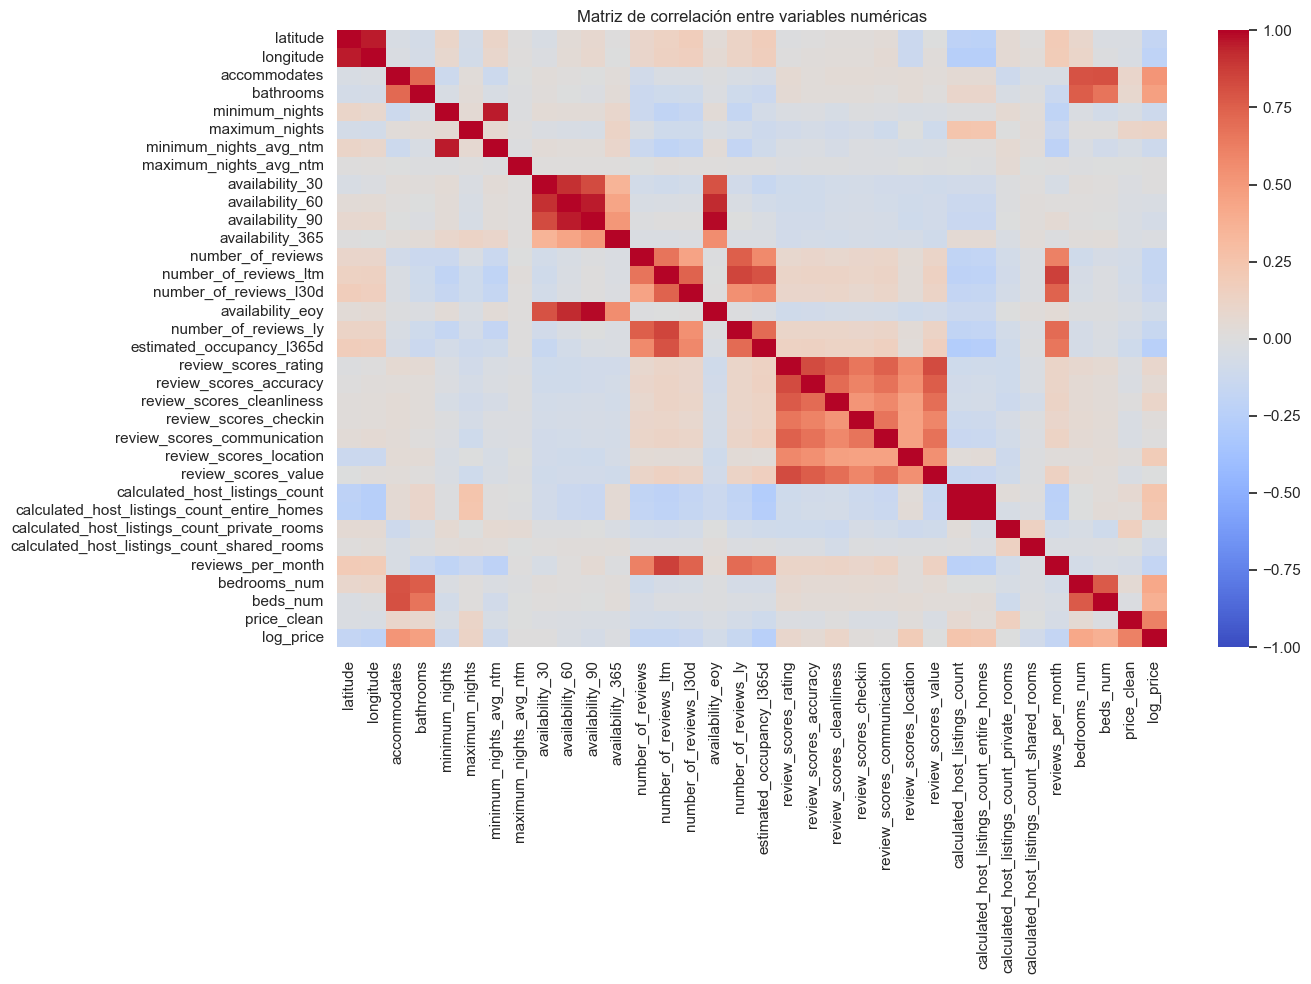

In [18]:
# Correlación de Pearson
corr_matrix = corr_df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1
)
plt.title("Matriz de correlación entre variables numéricas")
plt.tight_layout()
plt.show()

In [19]:
# Variables más correlacionadas con price_clean
corr_price = (
    corr_matrix["price_clean"]
    .drop("price_clean")
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .to_frame("corr_price")
)

# Variables más correlacionadas con log_price
corr_log_price = (
    corr_matrix["log_price"]
    .drop("log_price")
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .to_frame("corr_log_price")
)

top_corr = corr_price.join(corr_log_price, how="outer")
top_corr.head(15)

,corr_price,corr_log_price
accommodates,0.0997,0.5157
availability_30,-0.0208,0.0067
availability_365,-0.0381,-0.0164
availability_60,-0.0277,-0.0365
availability_90,-0.0346,-0.0684
availability_eoy,-0.0369,-0.0798
bathrooms,0.0797,0.4655
bedrooms_num,0.0516,0.4233
beds_num,-0.0208,0.3769
calculated_host_listings_count,0.0675,0.2434


### Interpretación inicial
En la tabla anterior deben observarse las variables numéricas más relacionadas con el precio.  
Para el análisis bivariado trabajaremos con las variables de mayor magnitud en `corr_log_price`, ya que `log_price` suele comportarse mejor cuando el precio está muy sesgado.

In [20]:
# Seleccionar top variables para análisis bivariado
top_vars = corr_log_price.head(6).index.tolist()
top_vars

['price_clean',
 'accommodates',
 'bathrooms',
 'bedrooms_num',
 'beds_num',
 'estimated_occupancy_l365d']

## 5. Relaciones bivariadas: scatterplots y tendencia

Se grafican las variables numéricas más relevantes contra:
- `price_clean`
- `log_price`

Visualmente interesa detectar:
- tendencia lineal positiva o negativa,
- curvaturas,
- dispersión,
- presencia de outliers.

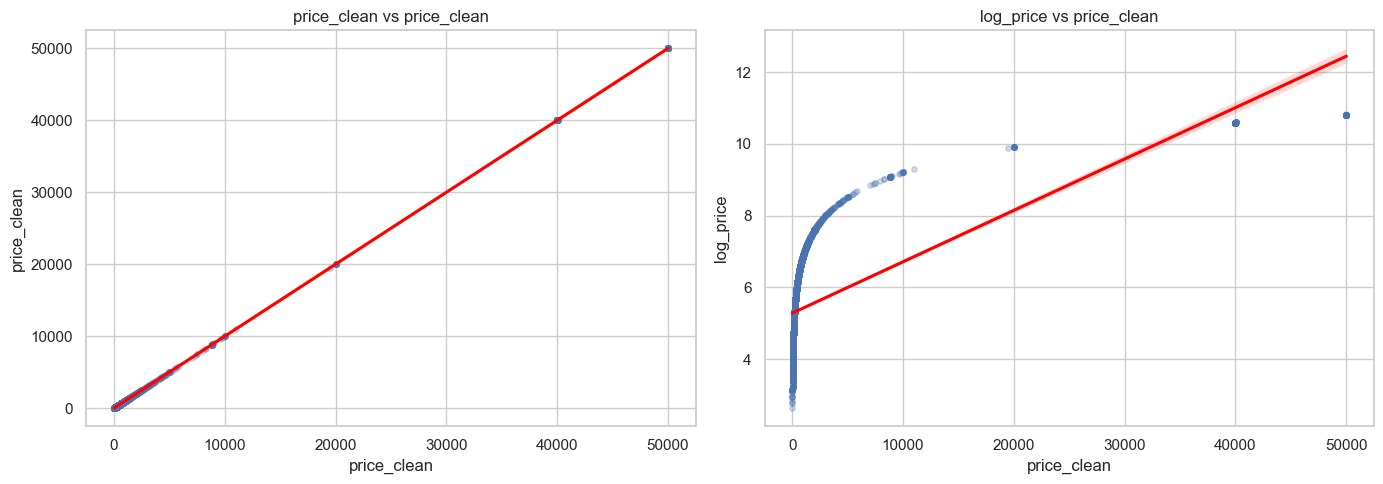

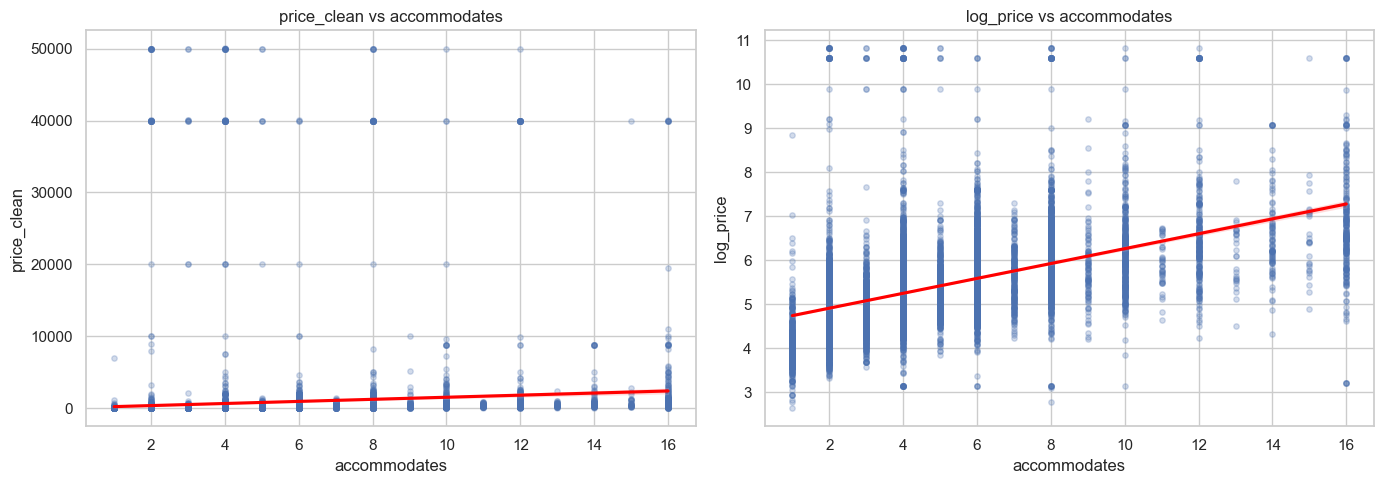

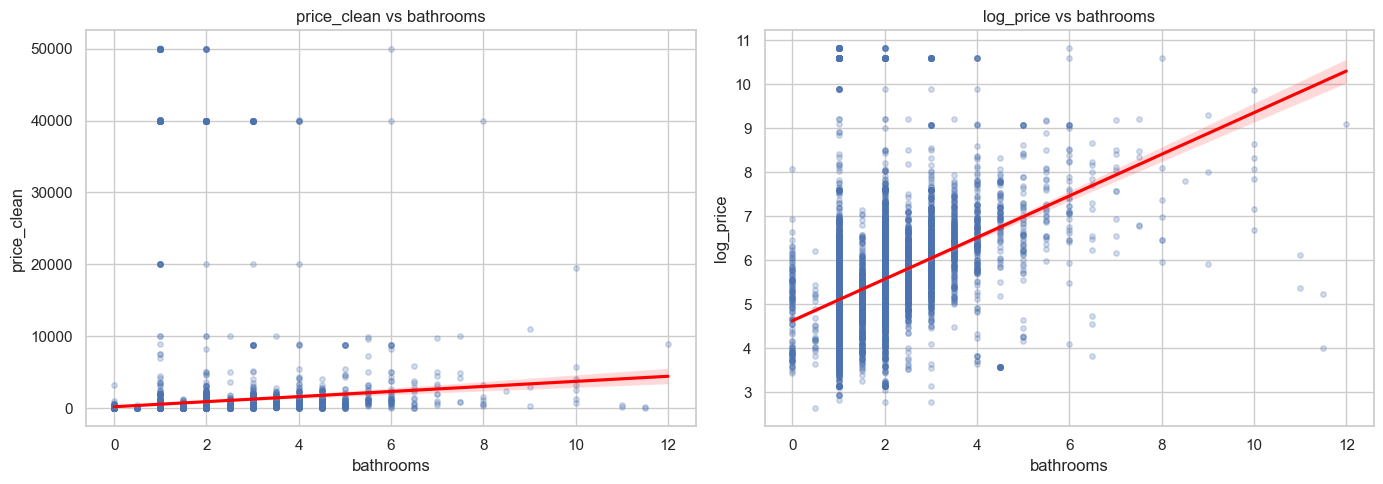

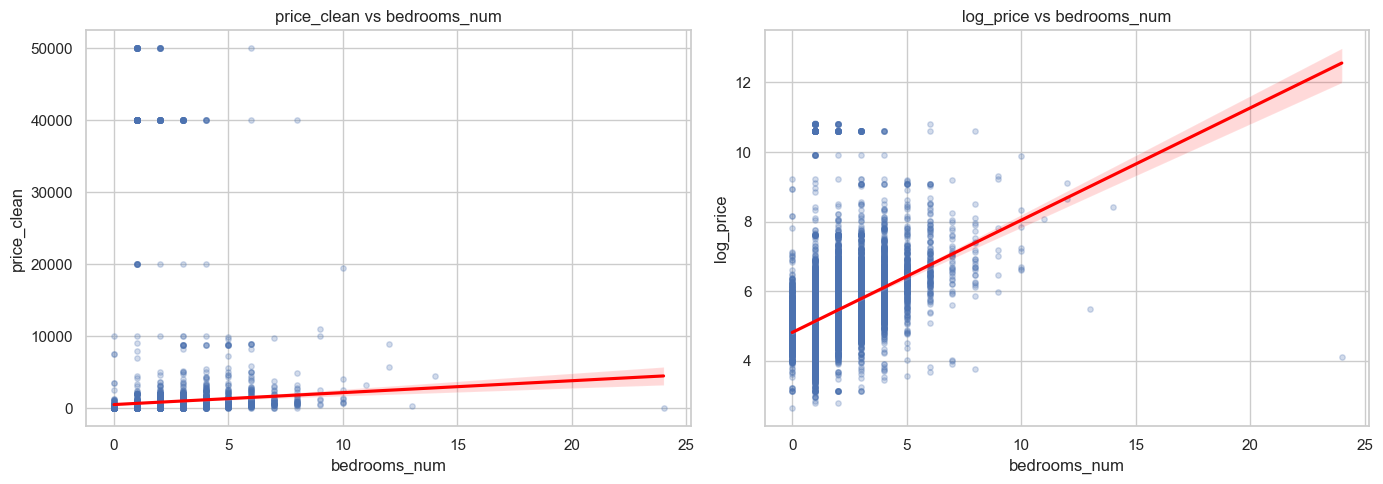

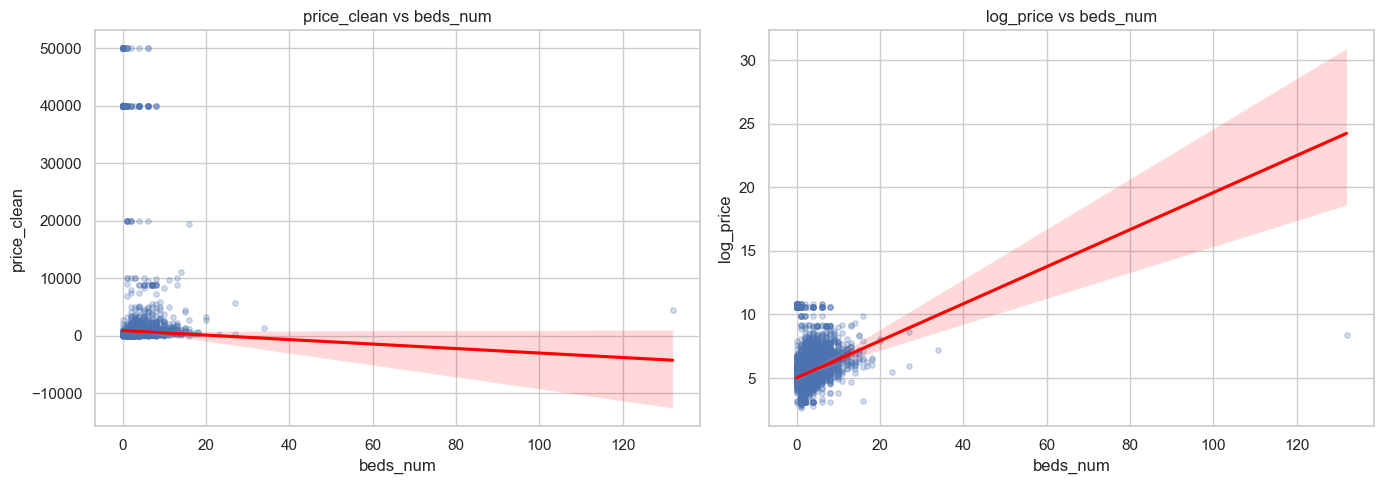

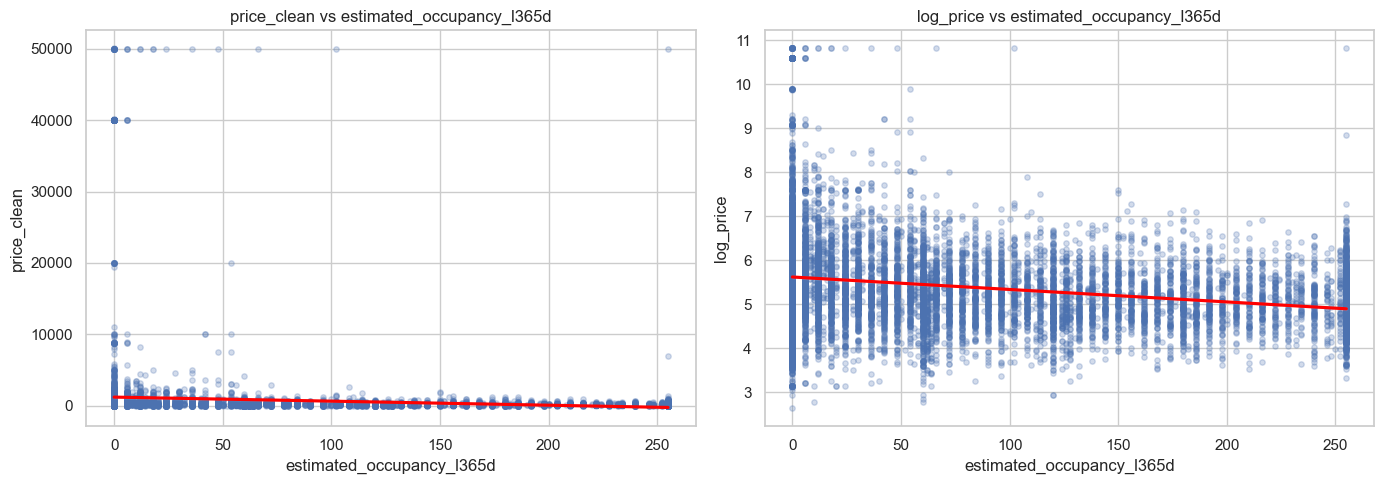

In [21]:
for var in top_vars:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.regplot(
        data=df_num.sample(min(12000, len(df_num)), random_state=42),
        x=var, y="price_clean",
        scatter_kws={"alpha": 0.25, "s": 15},
        line_kws={"color": "red"},
        ax=axes[0]
    )
    axes[0].set_title(f"price_clean vs {var}")
    axes[0].set_xlabel(var)
    axes[0].set_ylabel("price_clean")

    sns.regplot(
        data=df_num.sample(min(12000, len(df_num)), random_state=42),
        x=var, y="log_price",
        scatter_kws={"alpha": 0.25, "s": 15},
        line_kws={"color": "red"},
        ax=axes[1]
    )
    axes[1].set_title(f"log_price vs {var}")
    axes[1].set_xlabel(var)
    axes[1].set_ylabel("log_price")

    plt.tight_layout()
    plt.show()

## 6. Correlación de Pearson y Spearman para variables clave

Pearson mide asociación lineal.  
Spearman ayuda a detectar asociaciones monótonas, incluso cuando no son perfectamente lineales.

In [22]:
# seleccionar datos
sample_df = df_num[top_vars + ["price_clean", "log_price"]].dropna().copy()

# asegurar que todo sea numérico
sample_df = sample_df.apply(pd.to_numeric, errors="coerce")

# matriz de correlación Spearman
corr_matrix = sample_df.corr(method="spearman")

# correlación contra log_price
spearman_df = (
    corr_matrix["log_price"]
    .drop("log_price")
    .reset_index()
)

spearman_df.columns = ["variable", "spearman_log_price"]

# ordenar por correlación absoluta
spearman_df["abs_corr"] = spearman_df["spearman_log_price"].abs()

spearman_df = spearman_df.sort_values("abs_corr", ascending=False)

spearman_df = spearman_df.drop(columns="abs_corr")

spearman_df

,variable,spearman_log_price
0,price_clean,1.0000
6,price_clean,1.0000
1,accommodates,0.5955
2,bathrooms,0.5197
4,beds_num,0.5093
3,bedrooms_num,0.5031
5,estimated_occupancy_l365d,-0.2594


## 7. Pruebas de normalidad

Dado que el dataset es muy grande, se toma una muestra reproducible de 5,000 observaciones para aplicar **Shapiro-Wilk** sobre:
- `price_clean`
- `log_price`

Además, se calcula asimetría (`skewness`) y curtosis para comparar ambas distribuciones.

In [23]:
# Muestra para normalidad
normality_sample = df_num[["price_clean", "log_price"]].dropna().sample(
    n=min(5000, len(df_num)),
    random_state=42
)

normality_results = []

for col in ["price_clean", "log_price"]:
    stat, p = shapiro(normality_sample[col])
    normality_results.append({
        "variable": col,
        "shapiro_stat": stat,
        "p_value": p,
        "skewness": skew(normality_sample[col]),
        "kurtosis": kurtosis(normality_sample[col], fisher=True)
    })

normality_df = pd.DataFrame(normality_results)
normality_df

,variable,shapiro_stat,p_value,skewness,kurtosis
0,price_clean,0.1212,0.0000,9.5934,93.4422
1,log_price,0.8818,0.0000,1.8099,6.9942


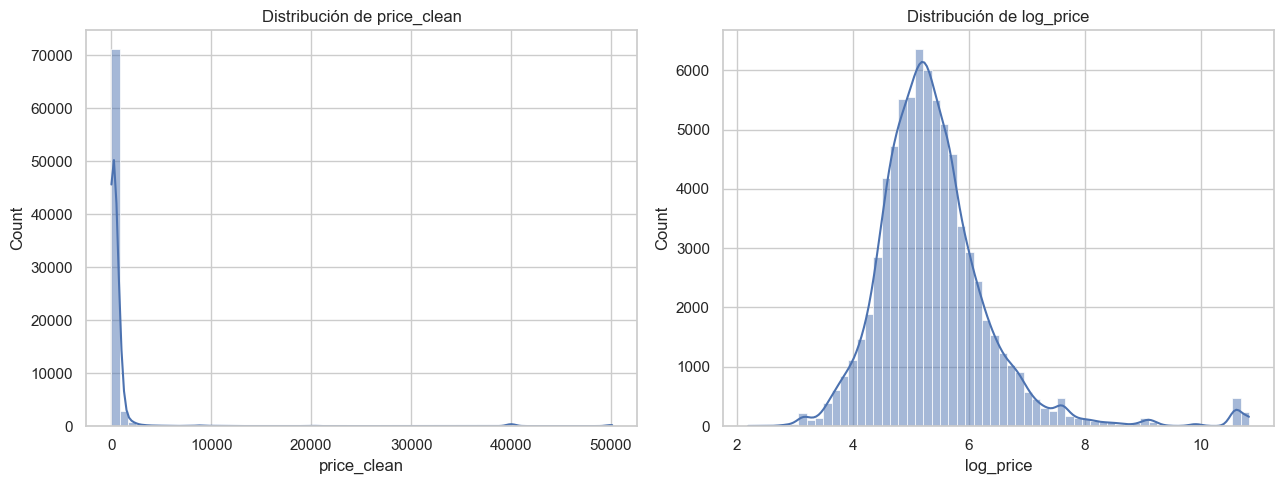

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df_num["price_clean"], bins=60, kde=True, ax=axes[0])
axes[0].set_title("Distribución de price_clean")

sns.histplot(df_num["log_price"], bins=60, kde=True, ax=axes[1])
axes[1].set_title("Distribución de log_price")

plt.tight_layout()
plt.show()

### Lectura esperada
- Si `price_clean` muestra fuerte asimetría y un p-value muy pequeño, entonces no sigue normalidad.
- Si `log_price` reduce la asimetría y luce más simétrica, la transformación logarítmica es apropiada para modelado posterior.

En datasets grandes, es común que la prueba formal rechace normalidad incluso cuando la forma visual mejora bastante.  
Por eso debe interpretarse junto con histogramas, boxplots y medidas de asimetría.

## 8. Conclusión técnica automática

La siguiente celda genera un pequeño resumen con base en las correlaciones observadas.

In [25]:
top3 = corr_log_price.head(3).copy()

print("=== Variables más correlacionadas con log_price ===")
display(top3)

print("\n=== Resumen sugerido ===")
for var, corr_val in top3["corr_log_price"].items():
    direction = "positiva" if corr_val > 0 else "negativa"
    strength = (
        "fuerte" if abs(corr_val) >= 0.50
        else "moderada" if abs(corr_val) >= 0.30
        else "débil"
    )
    print(f"- {var}: correlación {direction} de magnitud {strength} (r = {corr_val:.3f}).")

=== Variables más correlacionadas con log_price ===


,corr_log_price
price_clean,0.6110
accommodates,0.5157
bathrooms,0.4655



=== Resumen sugerido ===
- price_clean: correlación positiva de magnitud fuerte (r = 0.611).
- accommodates: correlación positiva de magnitud fuerte (r = 0.516).
- bathrooms: correlación positiva de magnitud moderada (r = 0.466).
